Enter your WRDS username [zyhhx]: zora0222
Enter your password: ········


WRDS recommends setting up a .pgpass file.


Create .pgpass file now [y/n]?:  n


You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Shape: (60, 5)
        date  permno        prc       ret    cumret
0 2020-01-31   14593  309.51001   0.05401   0.05401
1 2020-02-28   14593  273.35999  -0.11431 -0.066474
2 2020-03-31   14593  254.28999 -0.069762 -0.131599
3 2020-04-30   14593  293.79999  0.155374  0.003328
4 2020-05-29   14593     317.94  0.084956  0.088567


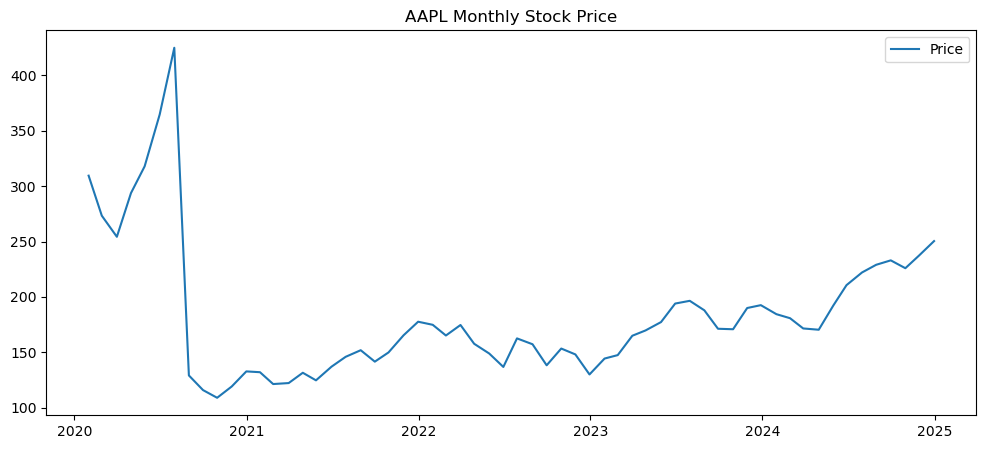

In [4]:
import wrds
import pandas as pd
import matplotlib.pyplot as plt
db = wrds.Connection()

ticker = "AAPL"
start_date = "2020-01-01"

sql = f"""
SELECT a.date, a.permno, a.prc, a.ret
FROM crsp.msf AS a
LEFT JOIN crsp.msfhdr AS b ON a.permno = b.permno
WHERE b.htsymbol = '{ticker}'
AND a.date >= '{start_date}'
ORDER BY a.date
"""

df = db.raw_sql(sql, date_cols=["date"])
db.close()

df = df.dropna()
df["cumret"] = (1 + df["ret"]).cumprod() - 1

print("Shape:", df.shape)
print(df.head())

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["prc"], label="Price")
plt.title("AAPL Monthly Stock Price")
plt.legend()
plt.savefig("AAPL_price.png")
plt.show()

df.to_excel("AAPL_WRDS_result.xlsx", index=False)